,n,Soma Iterativa,Soma Recursiva,Soma Fórmula,Fatorial Iterativo,Fatorial Recursivo,Busca Linear,Busca Binária,Verificação Primo
0,1,0.000003,0.000002,9.560000e-07,0.000001,6.700000e-07,0.000003,0.000002,0.000001
1,10,0.000003,0.000004,6.550000e-07,0.000003,3.298000e-06,0.000002,0.000003,0.000005
2,100,0.000008,0.000015,9.660000e-07,0.000016,3.275500e-05,0.000002,0.000004,0.000002
3,200,0.000014,0.000079,1.024000e-06,0.000034,7.390100e-05,0.000001,0.000005,0.000003
4,400,0.000041,0.000149,1.011000e-06,0.000122,1.961750e-04,0.000002,0.000006,0.000003


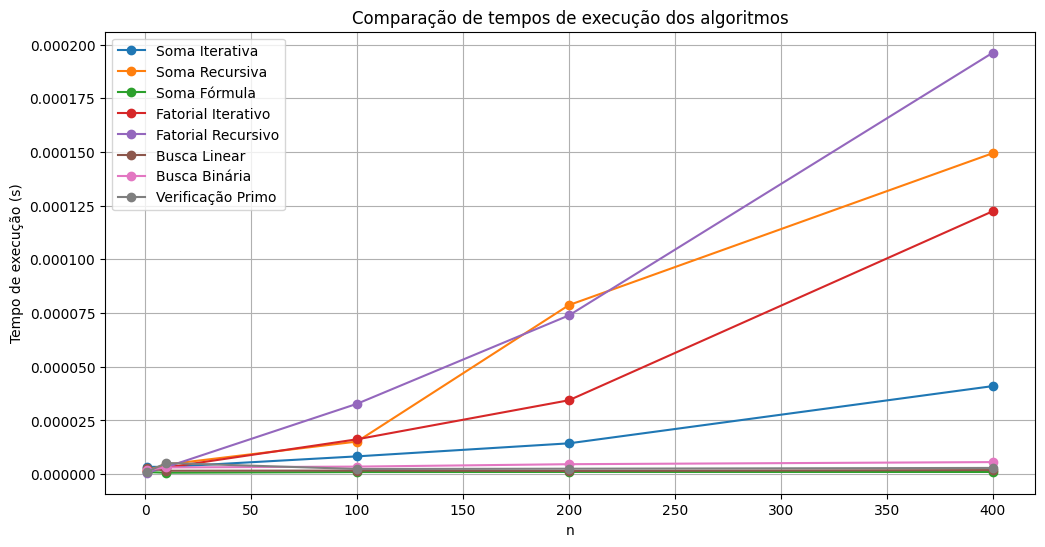

In [1]:
import time
import matplotlib.pyplot as plt
import pandas as pd

# Algoritmos solicitados

# 1. Soma de números de 1 a n
def soma_iterativa(n):
    total = 0
    for i in range(1, n+1):
        total += i
    return total

def soma_recursiva(n):
    if n == 0:
        return 0
    return n + soma_recursiva(n-1)

def soma_formula(n):
    return n * (n + 1) // 2

# 2. Fatorial
def fatorial_iterativo(n):
    resultado = 1
    for i in range(2, n+1):
        resultado *= i
    return resultado

def fatorial_recursivo(n):
    if n <= 1:
        return 1
    return n * fatorial_recursivo(n-1)

# 3. Busca linear
def busca_linear(lista, alvo):
    for i, elemento in enumerate(lista):
        if elemento == elemento:
            return i
    return -1

# 4. Busca binária
def busca_binaria(lista, alvo):
    esquerda, direita = 0, len(lista) - 1
    while esquerda <= direita:
        meio = (esquerda + direita) // 2
        if lista[meio] == alvo:
            return meio
        elif lista[meio] < alvo:
            esquerda = meio + 1
        else:
            direita = meio - 1
    return -1

# 5. Verificação de número primo
def eh_primo(n):
    if n < 2:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

# Função para medir tempo de execução
def medir_tempo(func, *args):
    inicio = time.perf_counter()
    func(*args)
    fim = time.perf_counter()
    return fim - inicio

# Parâmetros de teste
valores_n = [1,10, 100, 200, 400]
resultados = []

for n in valores_n:
    lista = list(range(n))
    alvo = n - 1  # último elemento

    resultados.append({
        "n": n,
        "Soma Iterativa": medir_tempo(soma_iterativa, n),
        "Soma Recursiva": medir_tempo(soma_recursiva, n),
        "Soma Fórmula": medir_tempo(soma_formula, n),
        "Fatorial Iterativo": medir_tempo(fatorial_iterativo, min(n, 500)),  # Limitar para evitar recursão profunda
        "Fatorial Recursivo": medir_tempo(fatorial_recursivo, min(n, 500)),
        "Busca Linear": medir_tempo(busca_linear, lista, alvo),
        "Busca Binária": medir_tempo(busca_binaria, lista, alvo),
        "Verificação Primo": medir_tempo(eh_primo, n)
    })

# Criar DataFrame
df = pd.DataFrame(resultados)

# Exibir tabela
display(df)

# Plotar gráficos
plt.figure(figsize=(12, 6))
for coluna in df.columns[1:]:
    plt.plot(df["n"], df[coluna], marker="o", label=coluna)

#plt.yscale("log")  # Escala log para melhor visualização
plt.xlabel("n")
plt.ylabel("Tempo de execução (s)")
plt.title("Comparação de tempos de execução dos algoritmos")
plt.legend()
plt.grid(True)
plt.show()